# Goal

## To Predict customer churn in e-commerce
Why it matters-
Reduce customer loss;
Improve retention strategy

# Data Understanding

In [99]:
#Load Dataset-Bring data into analysis environment
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(color_codes=True)

In [101]:
df = pd.read_excel('E_comm.xlsx')

In [102]:
#Data Overview-Understand structure, types, scale
df.head(n=8)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Mobile,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Mobile,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Mobile,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Mobile,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Mobile,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Mobile,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93


<Axes: xlabel='Churn', ylabel='count'>

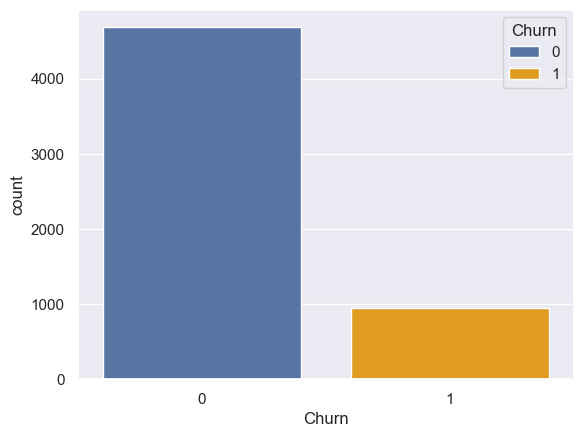

In [103]:
#Target Variable Analysis- Checking class imbalance for Churn vs no Churn
palette = ["#4C72B0", "orange"]
sns.countplot(x='Churn',hue='Churn', data=df, palette=palette)

In [107]:
df.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

In [109]:
df.shape[1]

20

In [111]:
#Check the number of unique values from all of the objects datatype
df.select_dtypes(include='object').nunique()

PreferredLoginDevice    2
PreferredPaymentMode    7
Gender                  2
PreferedOrderCat        5
MaritalStatus           3
dtype: int64

In [113]:
#Remove CustomerID Column
df.drop(columns='CustomerID', inplace=True)
df.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Mobile,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Mobile,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Mobile,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Mobile,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


# Exploratory Data Analysis 

In [116]:
cat_df = df.select_dtypes(include = 'object')

In [118]:
print(cat_df.columns)

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')


<Axes: xlabel='Churn', ylabel='DaySinceLastOrder'>

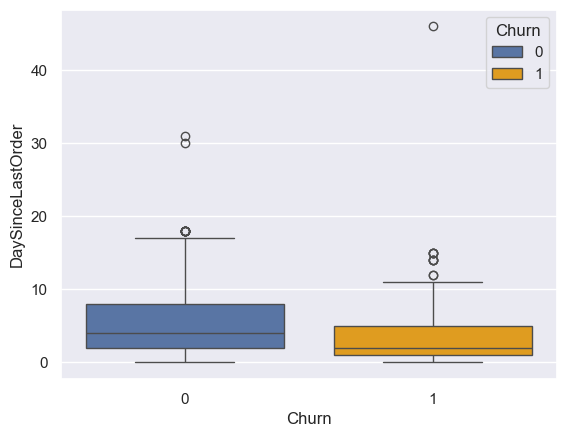

In [120]:
palette = ["#4C72B0", "orange"]
sns.boxplot(x='Churn',hue='Churn', y='DaySinceLastOrder', data=df,palette=palette)

Median (the middle line in the box)
Non-churned customers (0): ~4 days since last purchase
Churned customers (1): ~2 days since last purchase
So customers who churned generally waited for a shorter time before their last purchase.
This goes AGAINST the fundamental e-commerce Churn rule:
The longer a customer stays inactive, the higher the probability they Churn. So we need to check other features.

<Axes: xlabel='Churn', ylabel='CashbackAmount'>

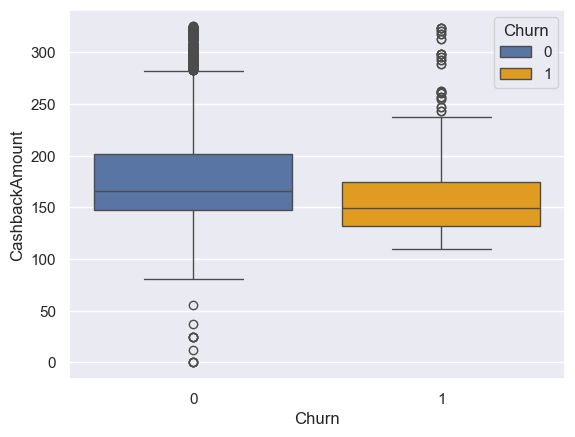

In [123]:
palette = ["#4C72B0", "orange"]
sns.boxplot(x='Churn',hue='Churn', y='CashbackAmount', data=df,palette=palette)

## Univariate Analysis

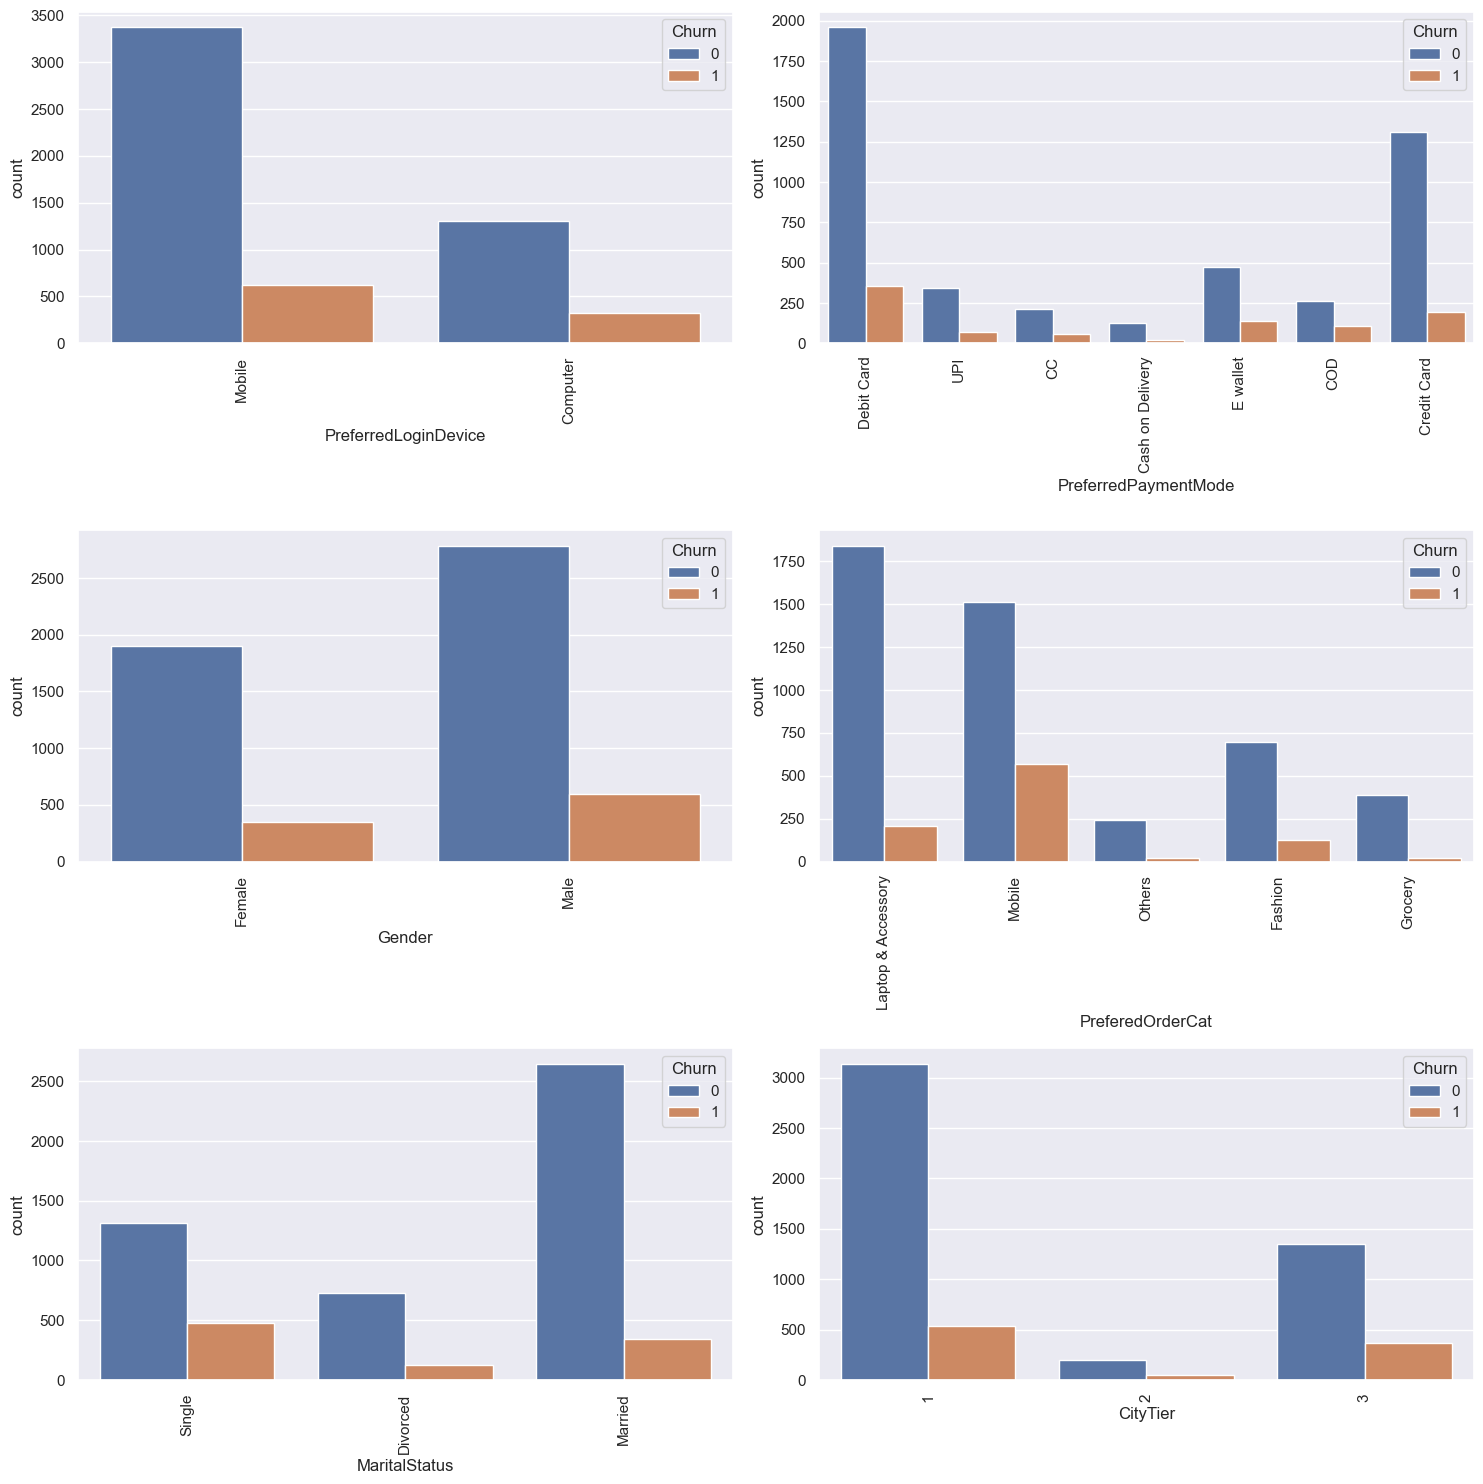

In [126]:
cat_vars = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus','CityTier']

# create figure with subplots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axs = axs.flatten()

# create barplot for each categorical variable
for i, var in enumerate(cat_vars):
    sns.countplot(x=var, hue='Churn', data=df, ax=axs[i])
    axs[i].set_xticks(axs[i].get_xticks())
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)

# adjust spacing between subplots
fig.tight_layout()

# show plot
plt.show()

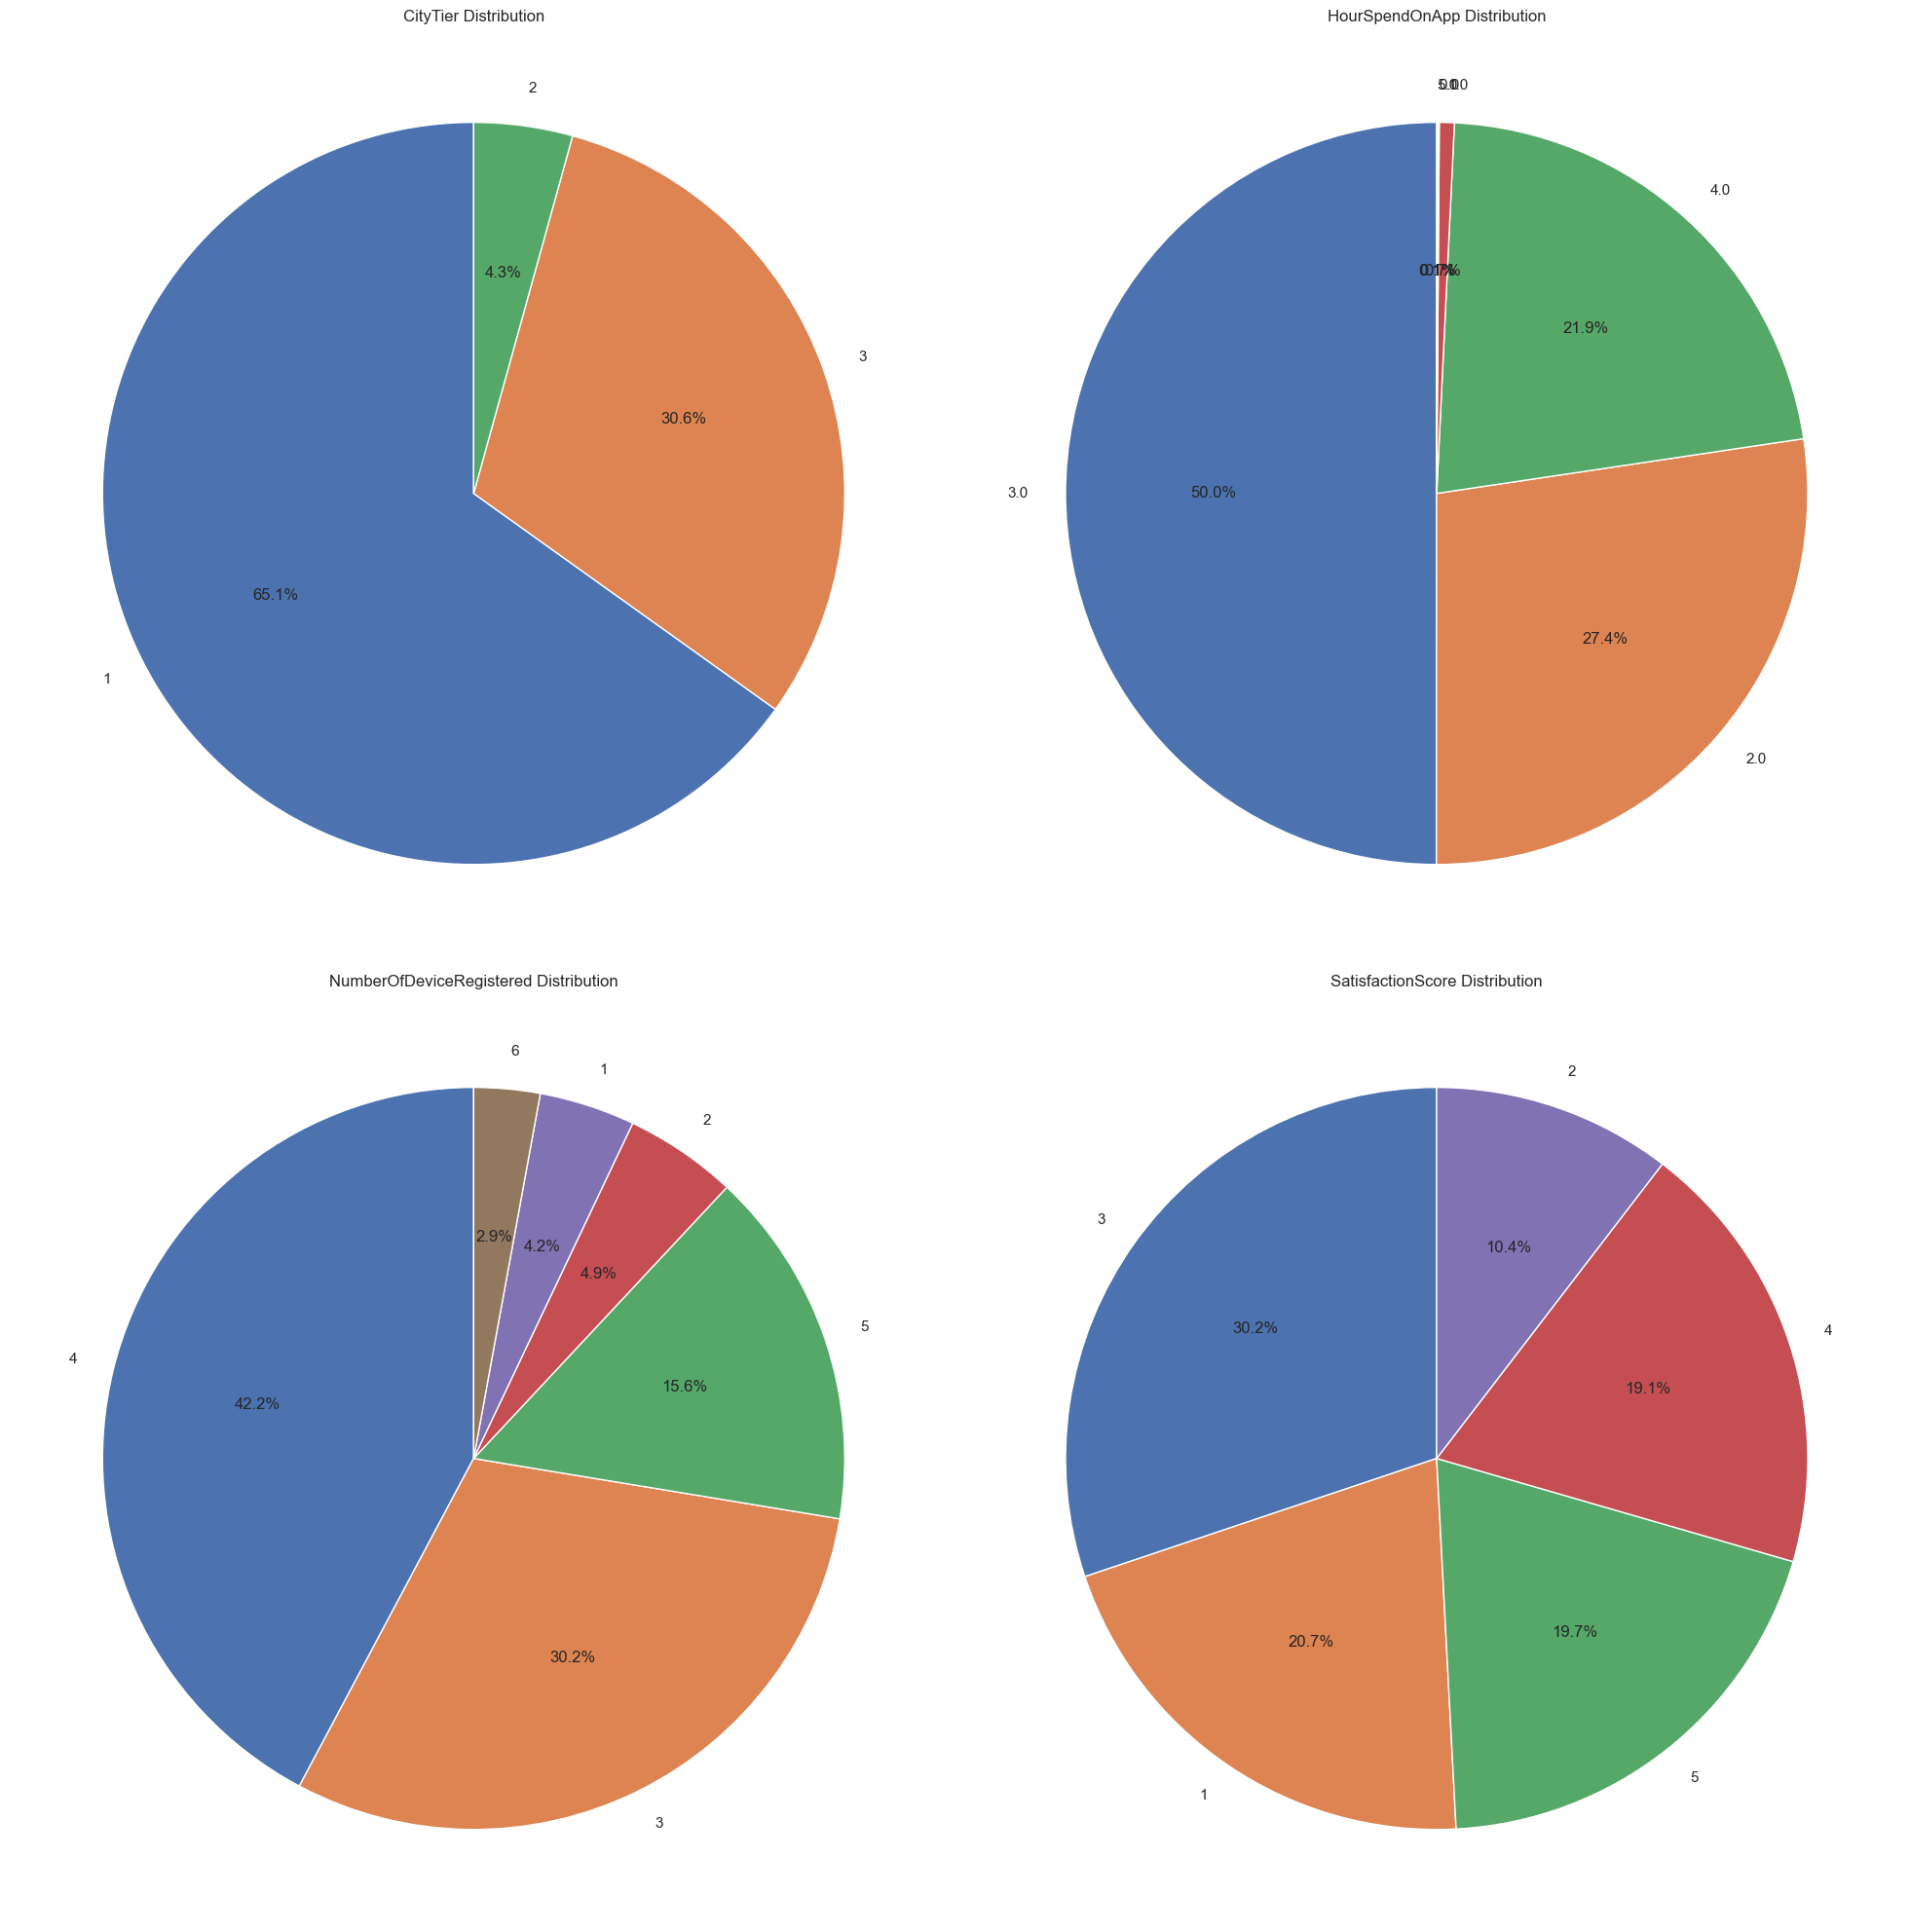

In [127]:
cat_vars = ['CityTier', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore']

# create a figure and axes
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 20))

# create a pie chart for each categorical variable
for i, var in enumerate(cat_vars):
    if i < len(axs.flat):
        # count the number of occurrences for each category
        cat_counts = df[var].value_counts()

        # create a pie chart
        axs.flat[i].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=90)

        # set a title for each subplot
        axs.flat[i].set_title(f'{var} Distribution')

# adjust spacing between subplots
fig.tight_layout()

# show the plot
plt.show()

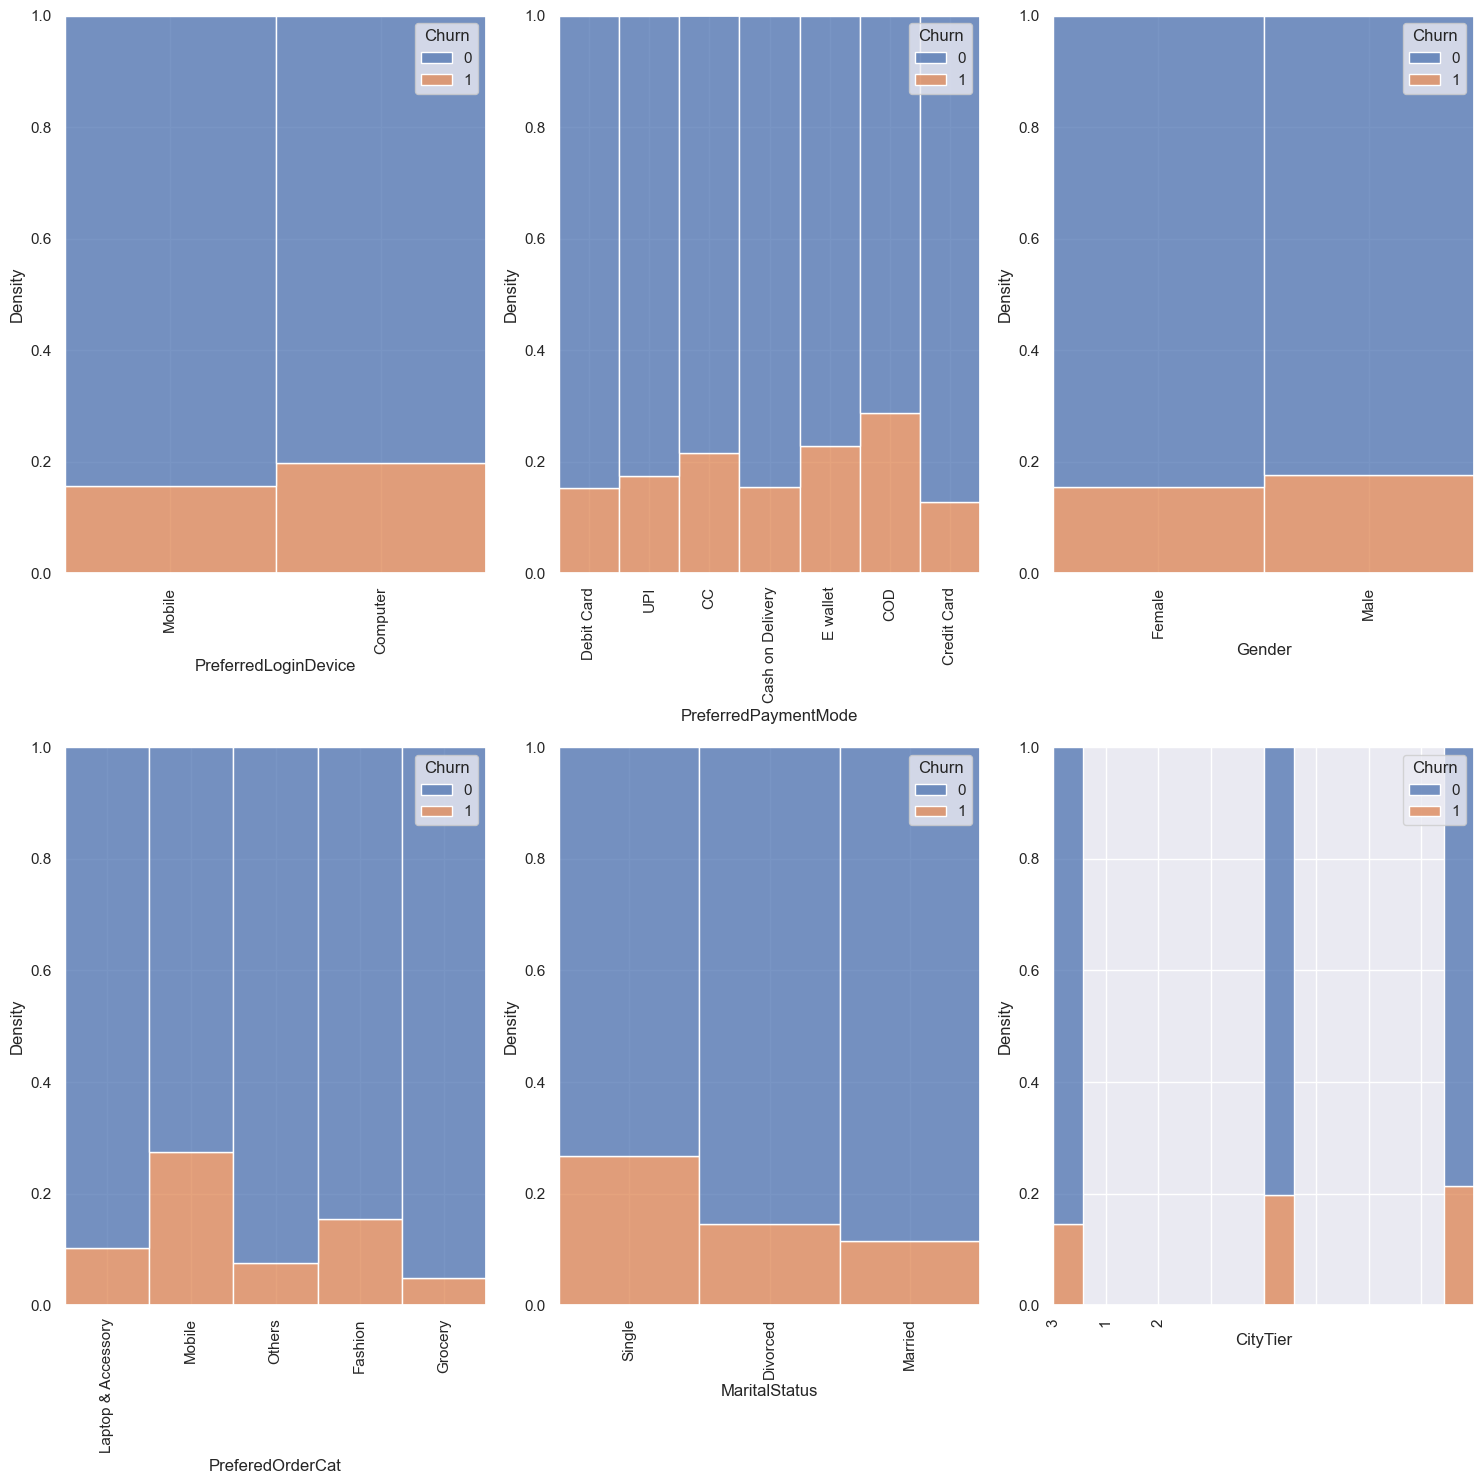

In [130]:
import warnings
warnings.filterwarnings("ignore")
# get list of categorical variables
cat_vars = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus','CityTier']

# create figure with subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 15))
axs = axs.flatten()

# create histplot for each categorical variable
for i, var in enumerate(cat_vars):
    sns.histplot(x=var, hue='Churn', data=df, ax=axs[i], multiple="fill", kde=False, element="bars", fill=True, stat='density')
    axs[i].set_xticklabels(df[var].unique(), rotation=90)
    axs[i].set_xlabel(var)

# adjust spacing between subplots
fig.tight_layout()

# show plot
plt.show()

In [131]:
cat_df = df.select_dtypes(include = ['int64','float64'])

In [134]:
print(cat_df.columns)

Index(['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
       'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')


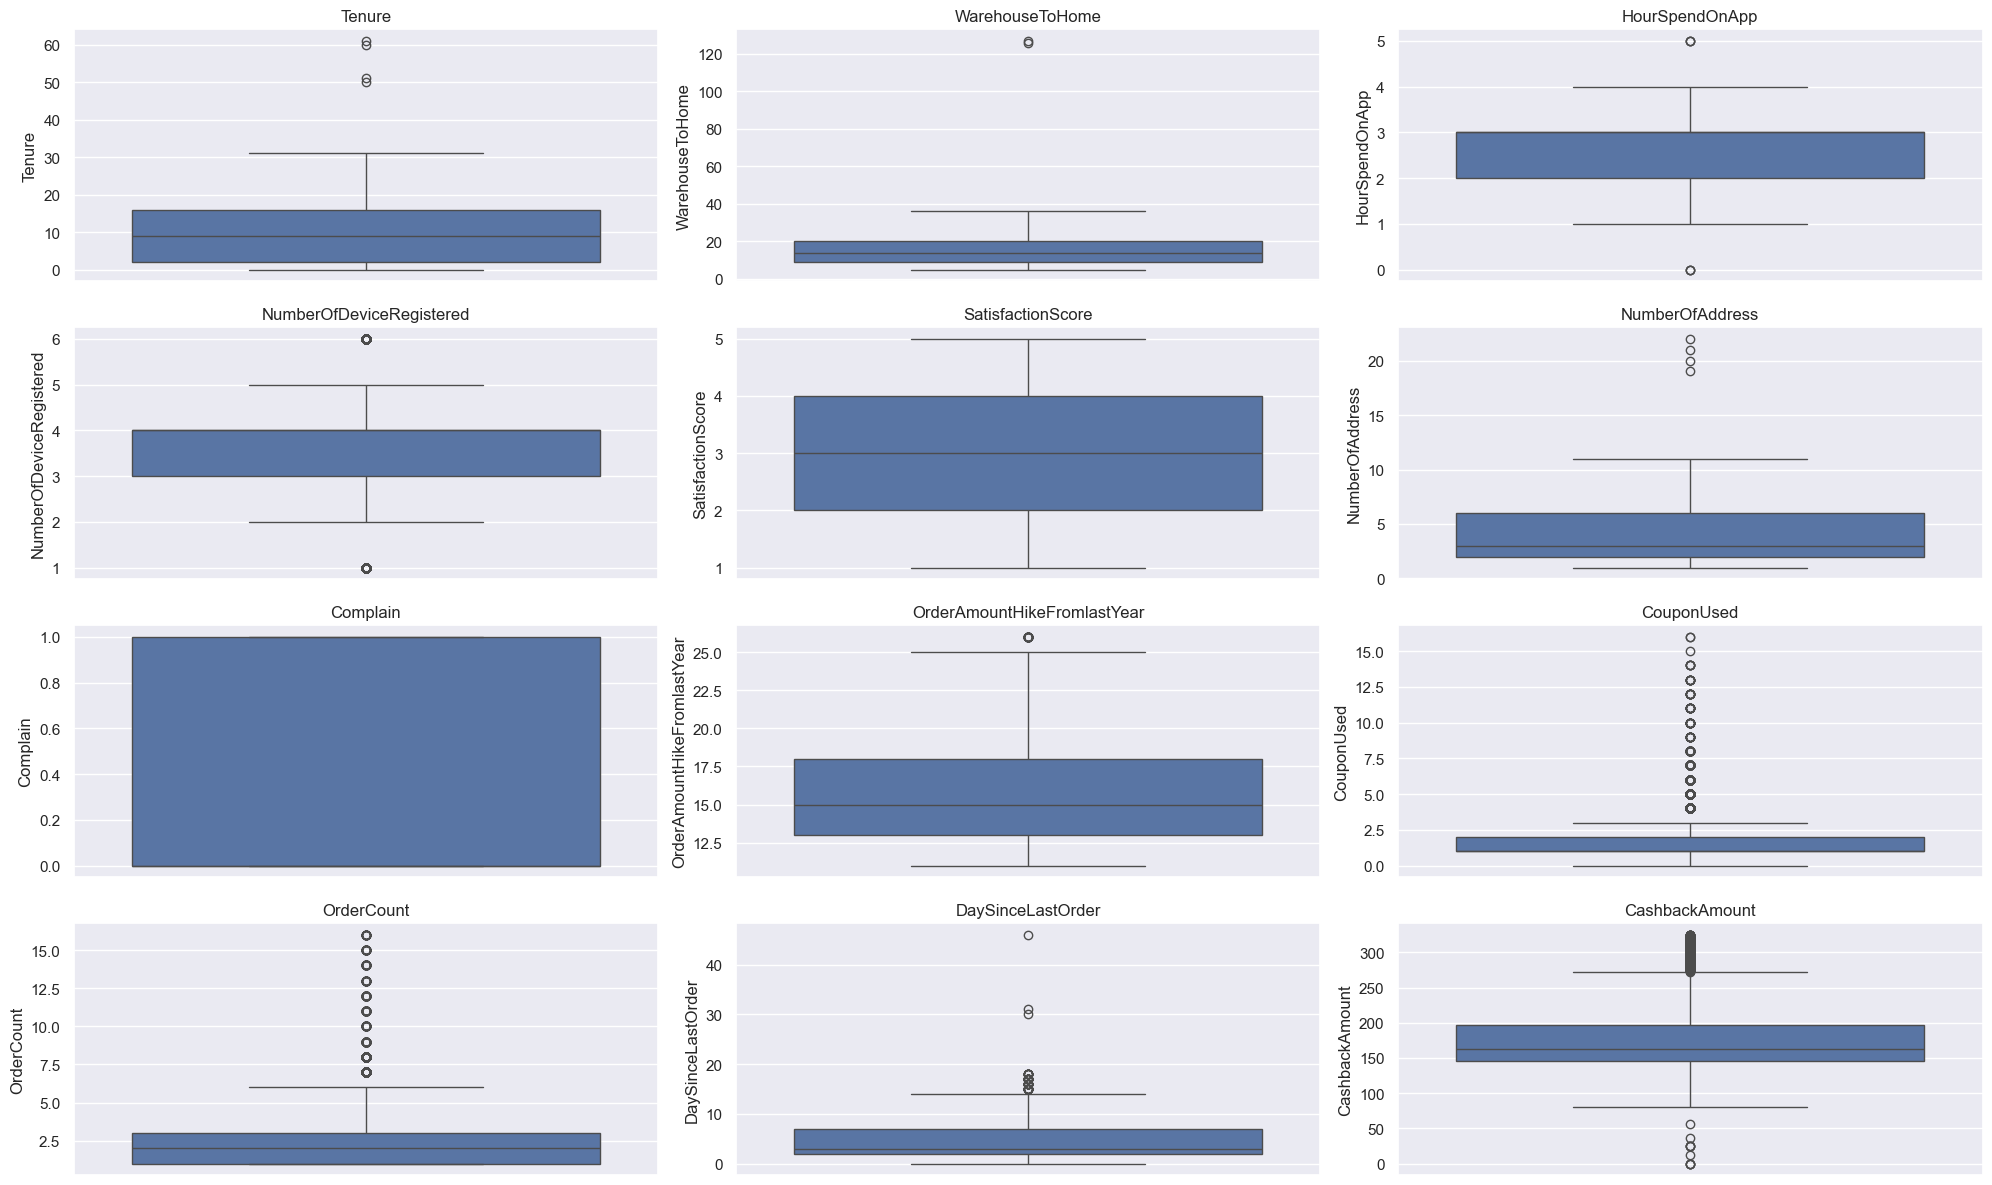

In [138]:
num_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 15))
axs = axs.flatten()

for i, var in enumerate(num_vars):
    sns.boxplot(y=df[var], ax=axs[i])
    axs[i].set_title(var)

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

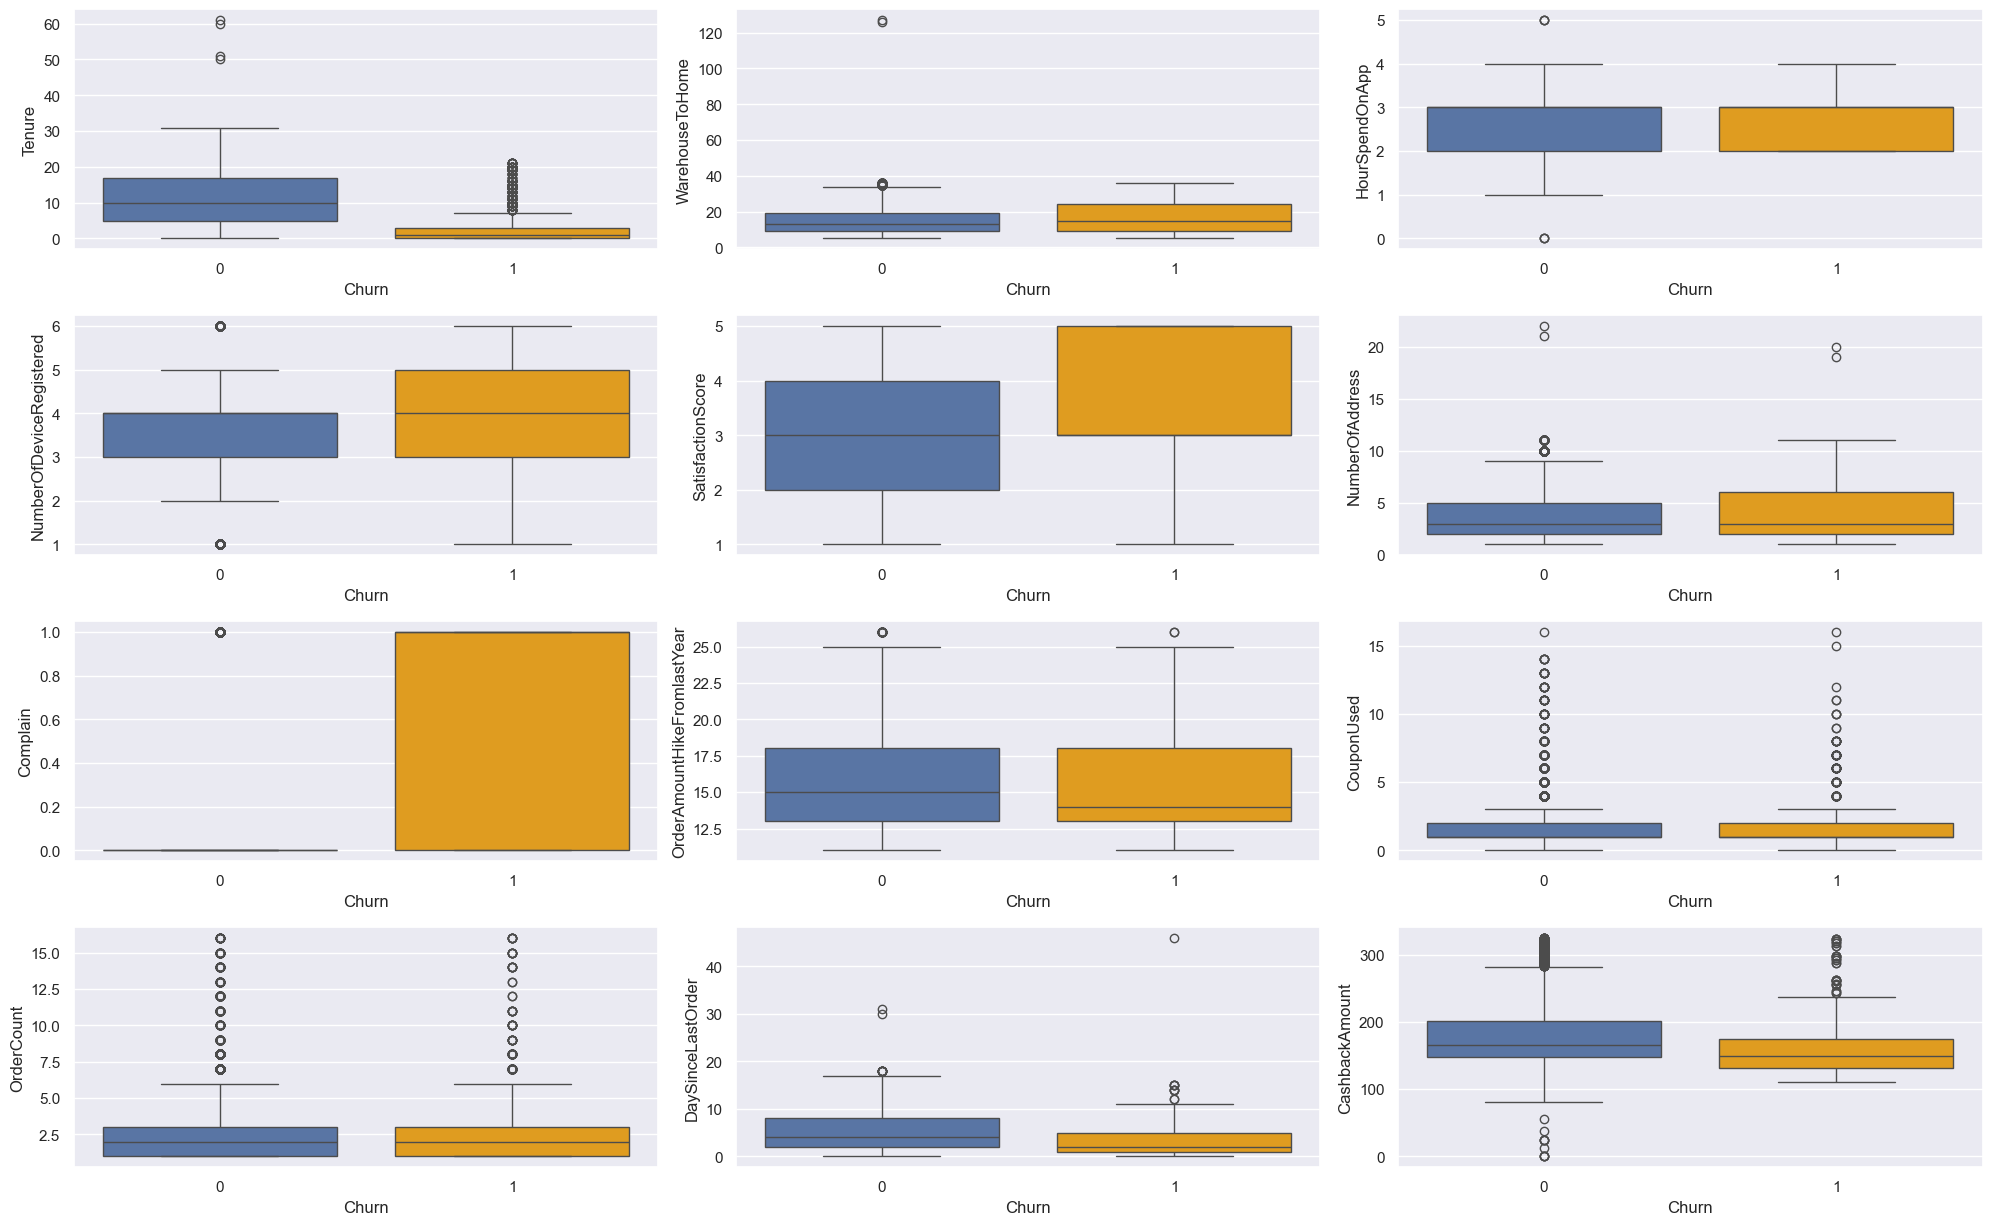

In [139]:
num_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 15))
axs = axs.flatten()

palette = ["#4C72B0", "orange"]

for i, var in enumerate(num_vars):
    sns.boxplot(y=var, x='Churn', data=df, ax=axs[i], palette=palette)

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

| Feature            | Importance wrt to Churn |
| ------------------ | ---------- |
| last_purchase_days | Strong     |
| orders_last_12m    | Moderate   |
| support_tickets    | Weak       |
| returns_last_12m   | Weak       |
| avg_order_value    | Weak       |
| discount_rate      | Weak       |
| age                | Weak       |
| tenure_months      | Weak       |

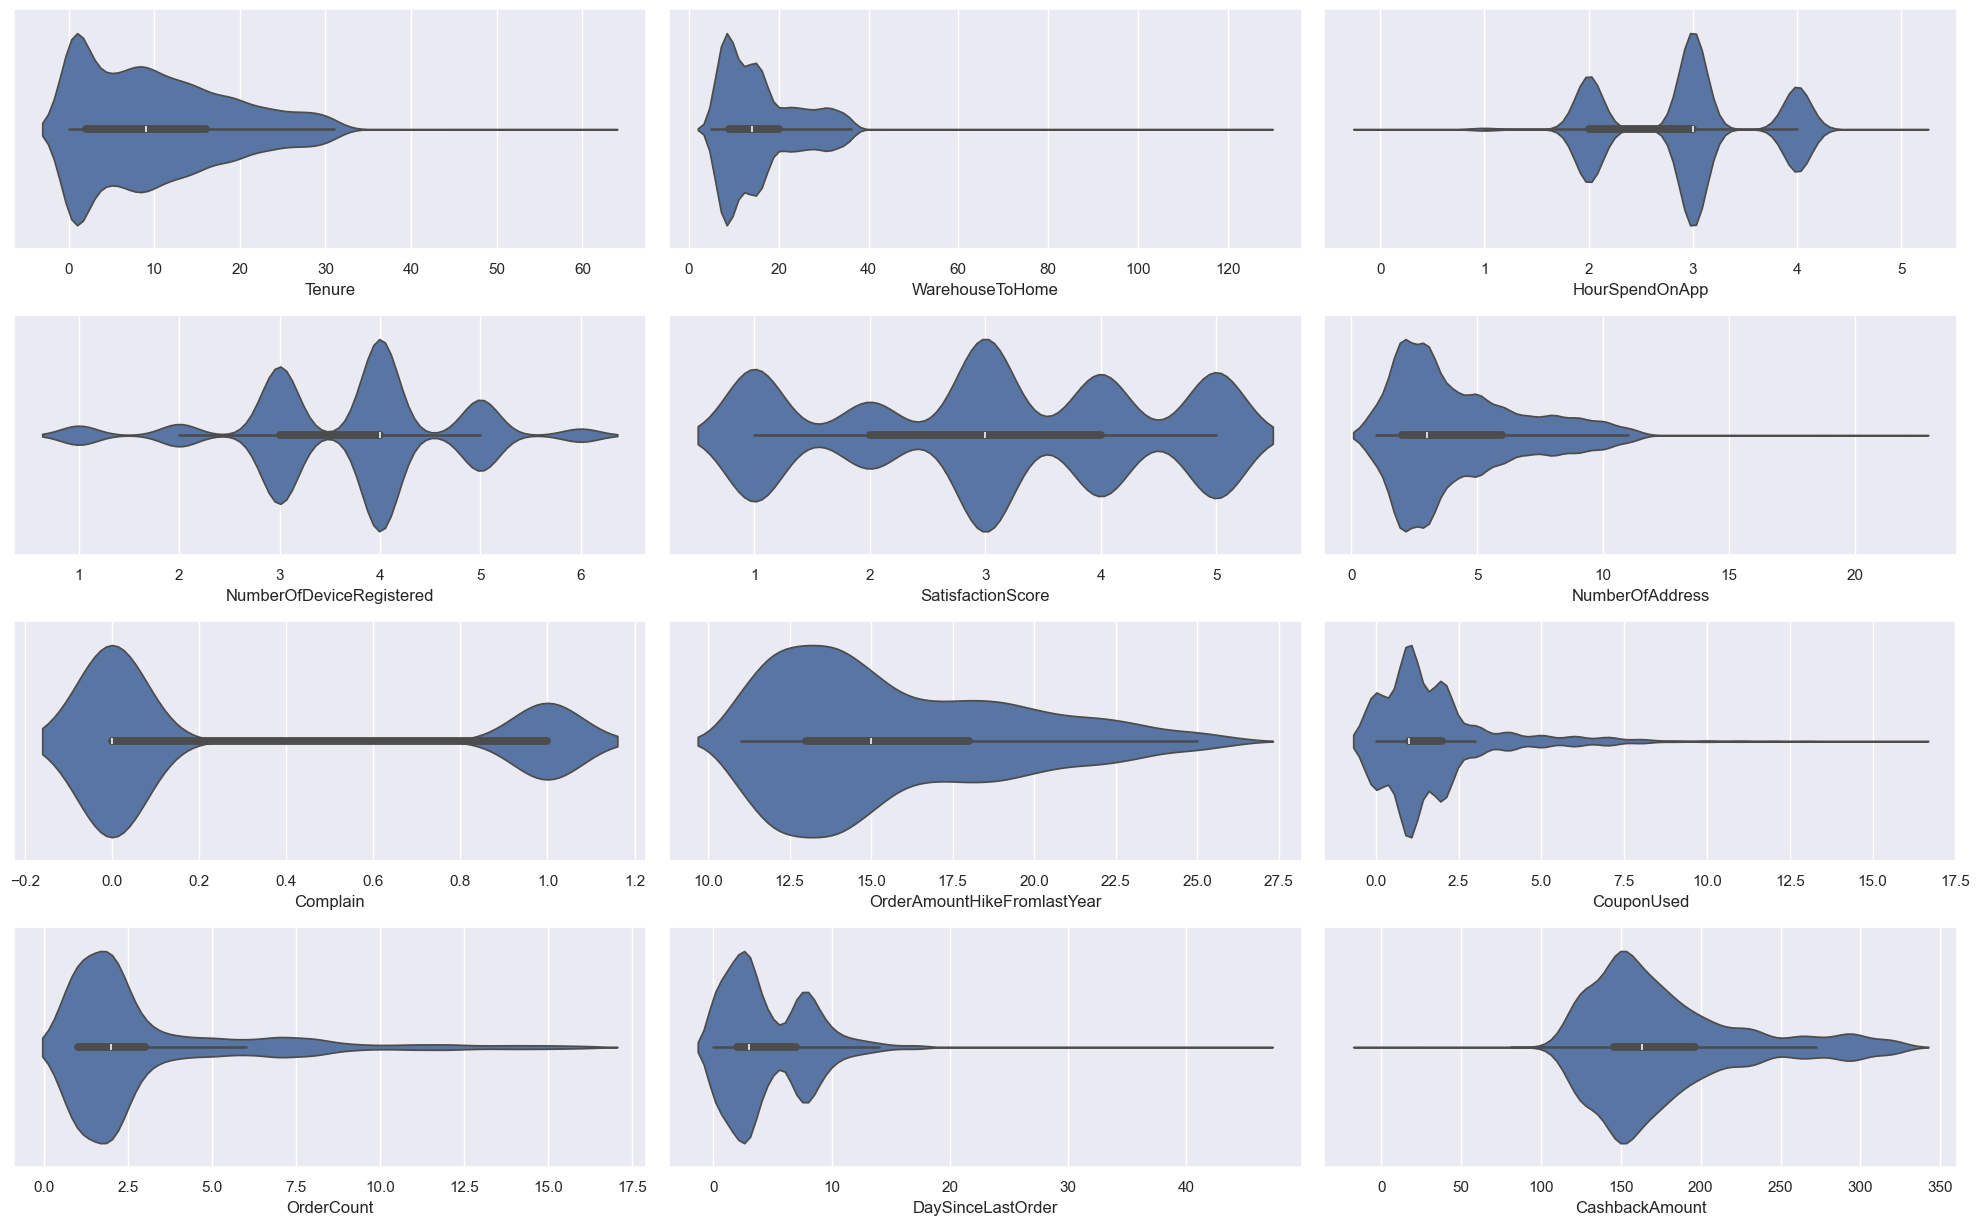

In [142]:
num_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 15))
axs = axs.flatten()


palette = ["#4C72B0", "orange"]


for i, var in enumerate(num_vars):
    sns.violinplot(x=var, data=df, ax=axs[i])

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])


fig.tight_layout()

plt.show()

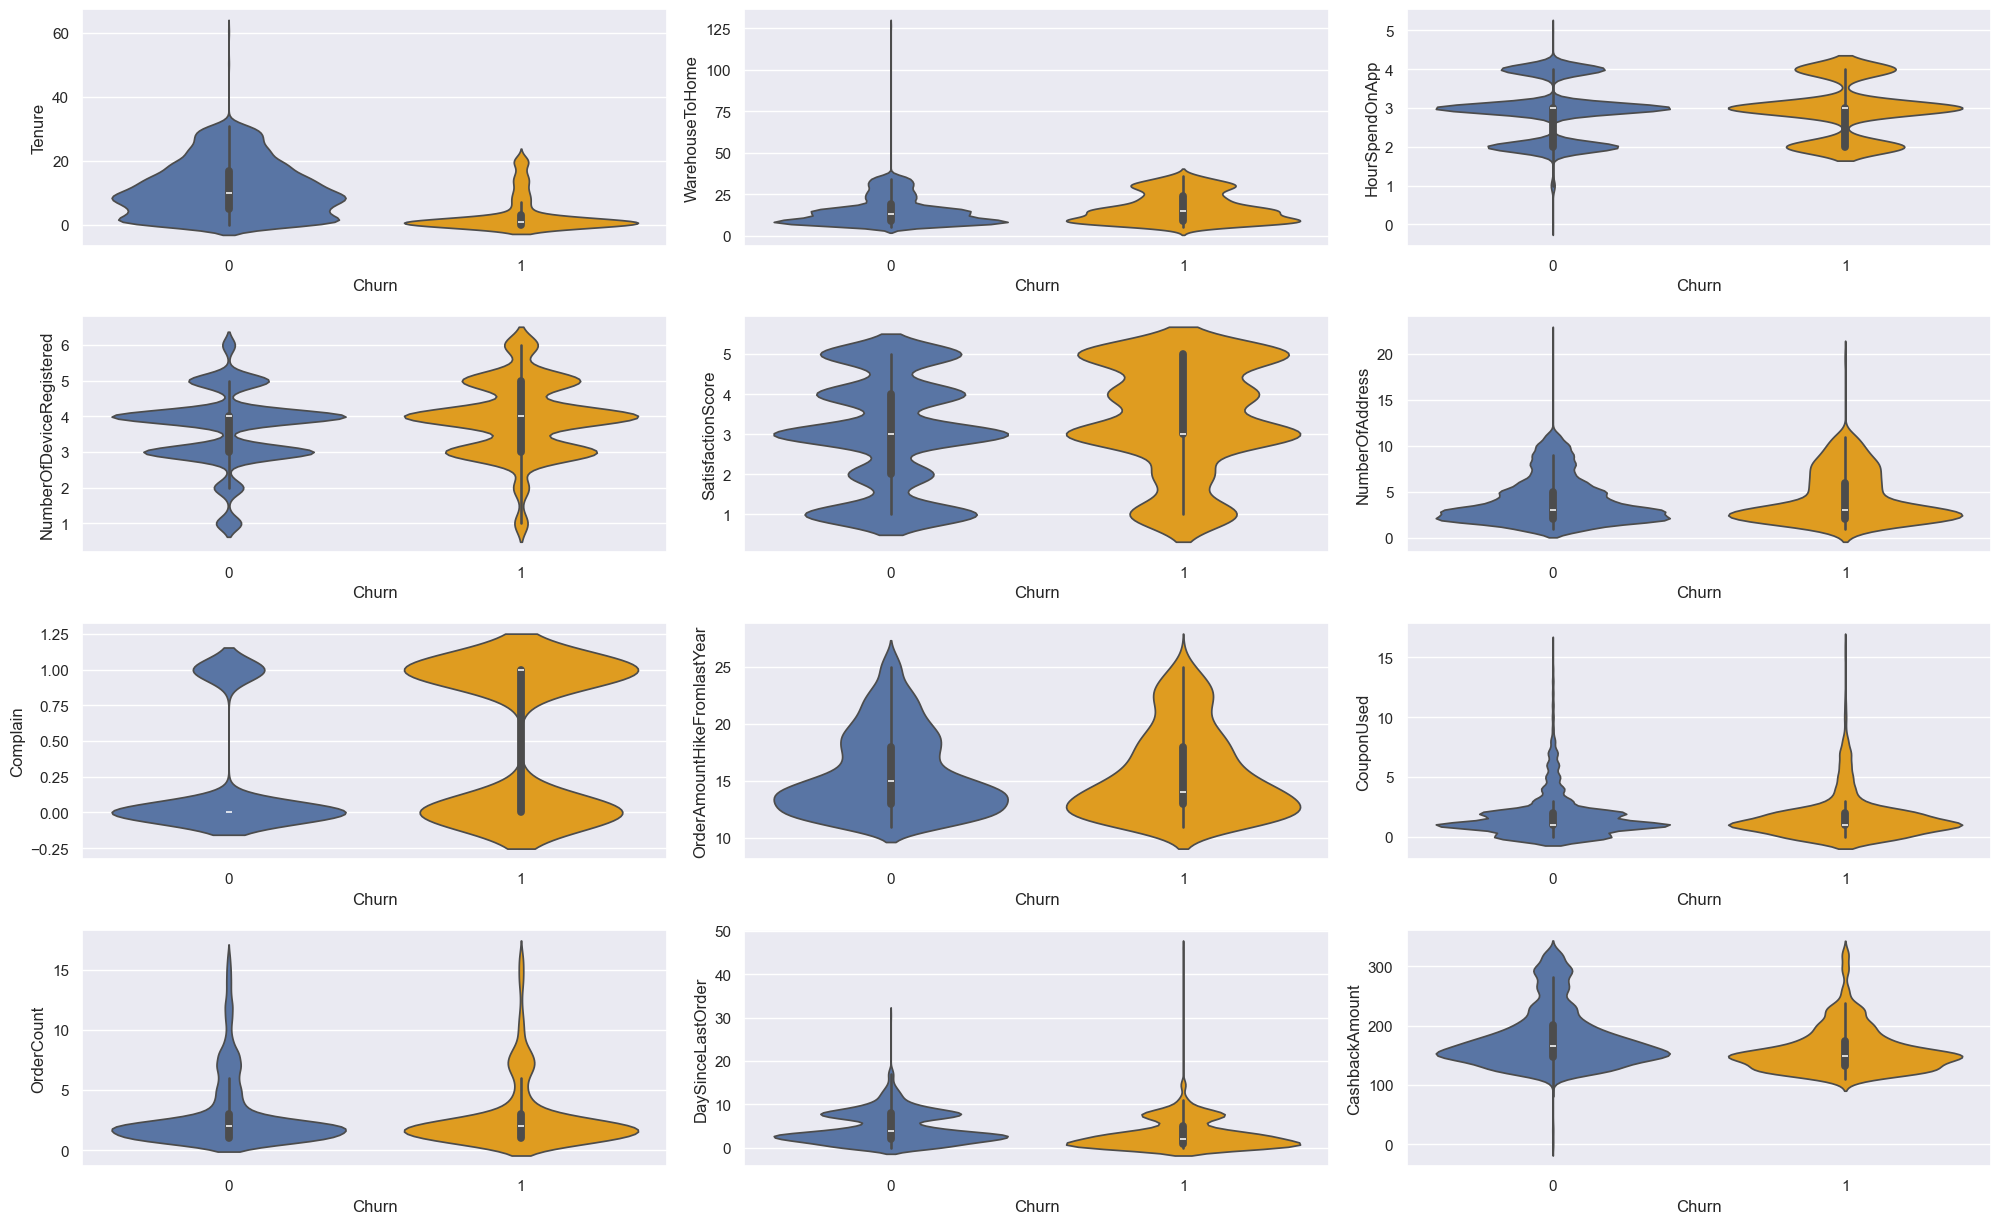

In [144]:
num_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 15))
axs = axs.flatten()

palette = ["#4C72B0", "orange"]

for i, var in enumerate(num_vars):
    sns.violinplot(y=var, x='Churn', data=df, ax=axs[i], palette=palette)

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])


fig.tight_layout()

plt.show()

## Bivariate Analysis

### Scatter Plot Analysis

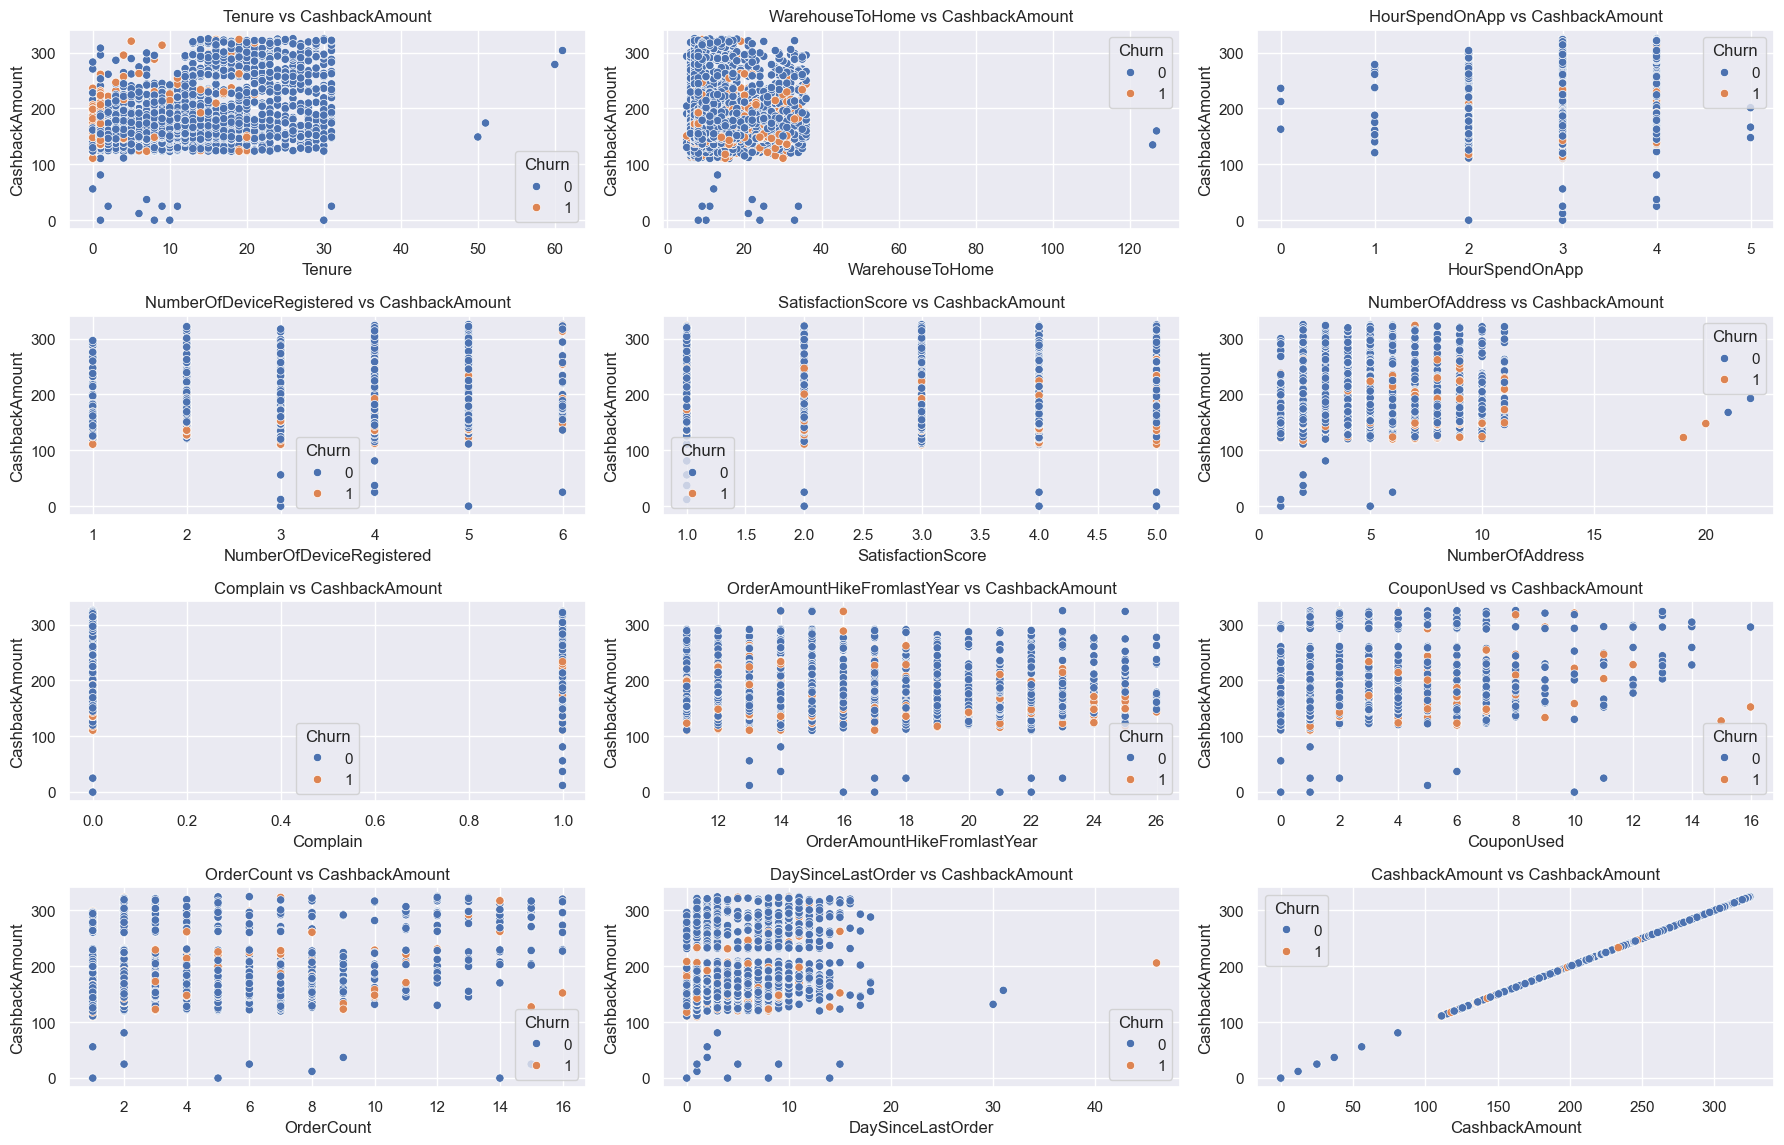

In [149]:
x_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(18, 14))
axs = axs.flatten()

for i, var in enumerate(x_vars):
    sns.scatterplot(
        x=var,
        y='CashbackAmount',
        hue='Churn',
        data=df,
        ax=axs[i]
    )
    axs[i].set_title(f'{var} vs CashbackAmount')

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])


plt.tight_layout()
plt.show()

Scatter plots revealed that behavioral variables such as purchase frequency have some relationship with inactivity, while demographic and monetary variables show little association. This suggests that Churn in this dataset is primarily driven by declining engagement rather than customer characteristics or spending power.

### Correlation Heat Map

<Axes: >

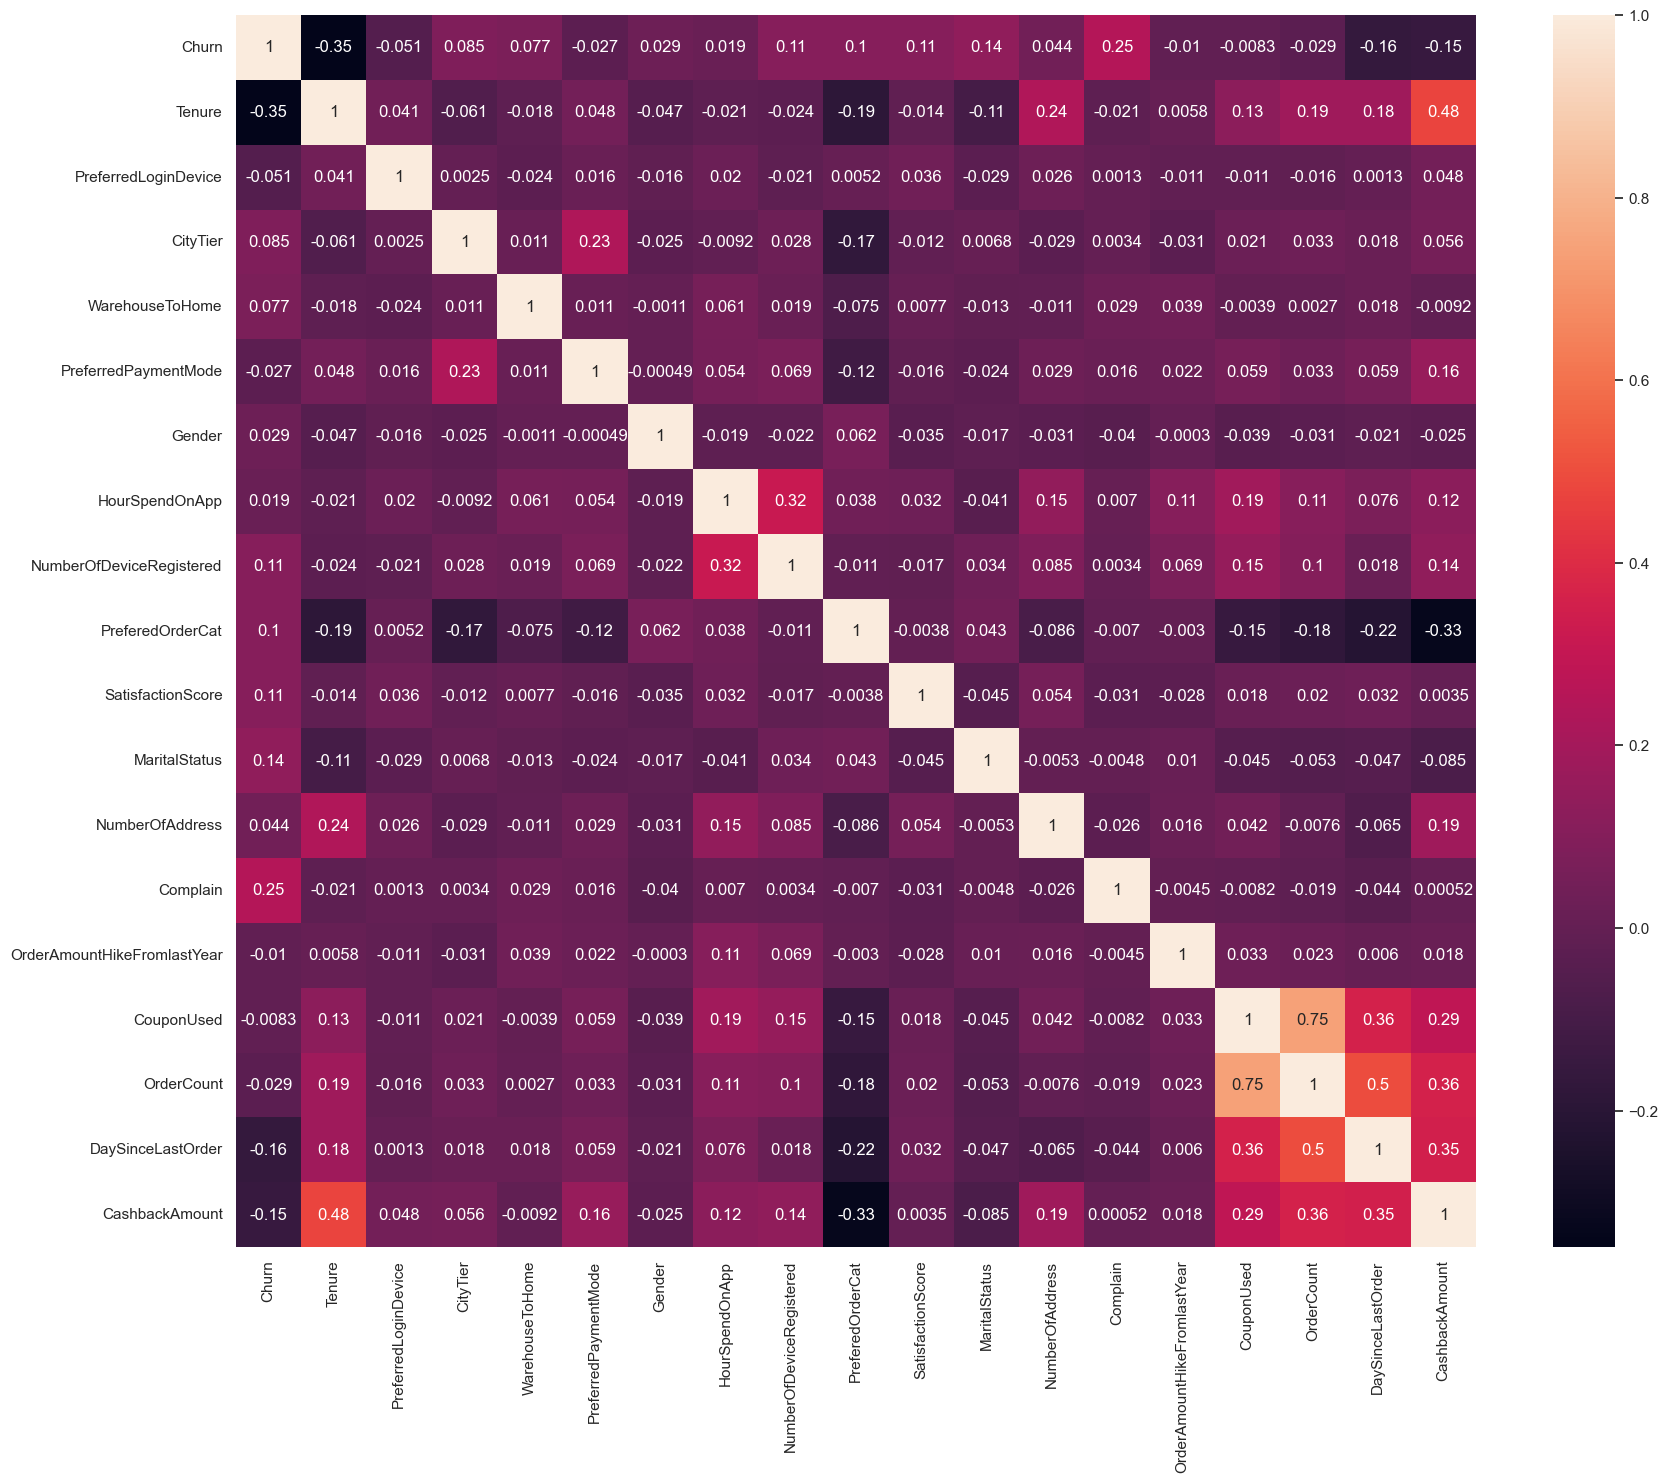

In [328]:
#Correlation Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(), fmt='.2g', annot=True)

# Data Preprocessing

In [154]:
from sklearn import preprocessing

# Loop over each column in the DataFrame where dtype is 'object'
for col in df.select_dtypes(include=['object']).columns:
    
    # Initialize a LabelEncoder object
    label_encoder = preprocessing.LabelEncoder()
    
    # Fit the encoder to the unique values in the column
    label_encoder.fit(df[col].unique())
    
    # Transform the column using the encoder
    df[col] = label_encoder.transform(df[col])
    
    # Print the column name and the unique encoded values
    print(f"{col}: {df[col].unique()}")

PreferredLoginDevice: [1 0]
PreferredPaymentMode: [4 6 0 2 5 1 3]
Gender: [0 1]
PreferedOrderCat: [2 3 4 0 1]
MaritalStatus: [2 0 1]


In [197]:
# Check missing value
missing = df.isnull().sum()*100 / df.shape[0]
missing[missing > 0].sort_values(ascending=False)
print(missing)

Churn                          0.000000
Tenure                         4.689165
PreferredLoginDevice           0.000000
CityTier                       0.000000
WarehouseToHome                4.458259
PreferredPaymentMode           0.000000
Gender                         0.000000
HourSpendOnApp                 4.529307
NumberOfDeviceRegistered       0.000000
PreferedOrderCat               0.000000
SatisfactionScore              0.000000
MaritalStatus                  0.000000
NumberOfAddress                0.000000
Complain                       0.000000
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
CashbackAmount                 0.000000
dtype: float64


# Train Test Split

In [159]:
from sklearn.model_selection import train_test_split
# Select the features (X) and the target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Outlier Treatment

In [161]:
cols = [
'DaySinceLastOrder',
'OrderAmountHikeFromlastYear',
'Tenure',
'OrderCount',
'CouponUsed',
'HourSpendOnApp',
'WarehouseToHome'
]

# Compute median from training data only
median_value = X_train[cols].median()

# Apply to both datasets
X_train[cols] = X_train[cols].fillna(median_value)
X_test[cols] = X_test[cols].fillna(median_value)

In [163]:
#Check missing value in each
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress               

In [166]:
#Remove Extreme Outliers
outlier_cols_remove = ['WarehouseToHome', 'DaySinceLastOrder']

iqr_bounds = {}

for col in outlier_cols_remove:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    iqr_bounds[col] = (lower, upper)

# Remove rows from training set only
for col, (lower, upper) in iqr_bounds.items():
    mask = (X_train[col] >= lower) & (X_train[col] <= upper)
    X_train = X_train[mask]
    y_train = y_train[mask]

In [168]:
#Cap Long-Tail Variables
outlier_cols_cap = ['CouponUsed', 'OrderCount', 'CashbackAmount']

cap_bounds = {}

for col in outlier_cols_cap:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.90)
    
    cap_bounds[col] = (lower, upper)

for col, (lower, upper) in cap_bounds.items():
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

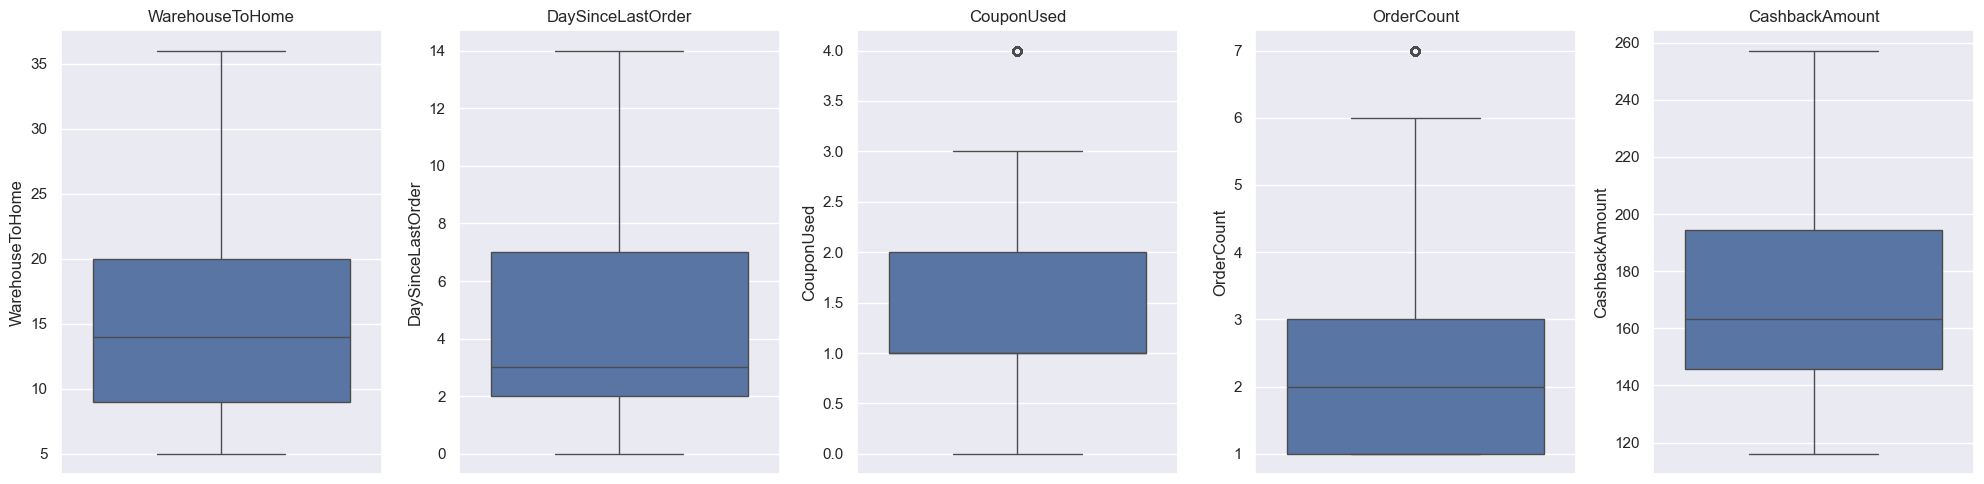

In [170]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_check = ['WarehouseToHome','DaySinceLastOrder','CouponUsed','OrderCount','CashbackAmount']

fig, axs = plt.subplots(1,5,figsize=(20,5))

for i, col in enumerate(cols_check):
    sns.boxplot(y=X_train[col], ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

# Feature Engineering

In [172]:
# Engagement score
X_train["engagement_score"] = X_train["OrderCount"] / (X_train["Tenure"] + 1)
X_test["engagement_score"]  = X_test["OrderCount"] / (X_test["Tenure"] + 1)

# Complaint rate
X_train["complaint_rate"] = X_train["Complain"] / (X_train["OrderCount"] + 1)
X_test["complaint_rate"]  = X_test["Complain"] / (X_test["OrderCount"] + 1)

# Recency ratio
X_train["recency_ratio"] = X_train["DaySinceLastOrder"] / (X_train["Tenure"] + 1)
X_test["recency_ratio"]  = X_test["DaySinceLastOrder"] / (X_test["Tenure"] + 1)

In [174]:
X_test.head()

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,...,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,engagement_score,complaint_rate,recency_ratio
4331,1.0,0,3,7.0,1,0,4.0,6,3,5,...,2,0,22.0,2.0,2.0,1.0,148.25,1.000000,0.000000,0.500000
1988,15.0,1,1,9.0,4,0,3.0,1,2,1,...,3,1,13.0,1.0,1.0,3.0,152.31,0.062500,0.500000,0.187500
3443,13.0,0,1,29.0,3,0,3.0,4,0,5,...,3,1,14.0,2.0,2.0,9.0,233.80,0.142857,0.333333,0.642857
4559,5.0,1,1,7.0,4,1,4.0,5,3,5,...,3,0,13.0,4.0,4.0,3.0,147.18,0.666667,0.000000,0.500000
4898,13.0,1,1,7.0,4,0,4.0,5,1,1,...,3,0,17.0,4.0,2.0,9.0,252.42,0.142857,0.000000,0.642857


In [176]:
X_train.head()

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,...,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,engagement_score,complaint_rate,recency_ratio
4478,1.0,1,1,12.0,4,0,3.0,4,3,4,...,3,1,13.0,1.0,2.0,3.0,149.78,1.000000,0.333333,1.5
3685,17.0,1,1,13.0,3,0,4.0,5,2,3,...,3,1,15.0,2.0,2.0,9.0,165.81,0.111111,0.333333,0.5
731,0.0,1,1,9.0,4,1,3.0,4,3,3,...,2,0,12.0,0.0,1.0,2.0,130.33,1.000000,0.000000,2.0
291,9.0,0,1,8.0,4,1,2.0,3,3,2,...,2,1,23.0,1.0,1.0,0.0,117.02,0.100000,0.500000,0.0
184,4.0,1,1,11.0,1,1,2.0,3,3,2,...,1,1,12.0,0.0,1.0,3.0,148.21,0.200000,0.500000,0.6


# Model Building

# Decision Tree Model

In [269]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
dtree = DecisionTreeClassifier(class_weight='balanced')
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3, 4],
    'random_state': [0, 42]
}

## Hyperparameter Tuning

In [272]:
# Perform a grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(dtree, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(grid_search.best_params_)

{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'random_state': 42}


In [273]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_leaf=1, min_samples_split=2, class_weight='balanced')
dtree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

## Model Evaluation

In [275]:
from sklearn.metrics import accuracy_score
y_pred = dtree.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 87.66 %


In [293]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,  jaccard_score, log_loss

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100 ,5), "%")
print("Precision:", round(precision_score(y_test, y_pred)*100 ,5), "%")
print("Recall:", round(recall_score(y_test, y_pred)*100 ,5), "%")
print("F1 Score:", round(f1_score(y_test, y_pred)*100 ,5), "%")
print("Jaccard Score:", round(jaccard_score(y_test, y_pred)*100 ,5), "%")
print("Log Loss:", log_loss(y_test, y_pred))

Accuracy: 87.65542 %
Precision: 58.27338 %
Recall: 87.56757 %
F1 Score: 69.9784 %
Jaccard Score: 53.8206 %
Log Loss: 4.44943856224448


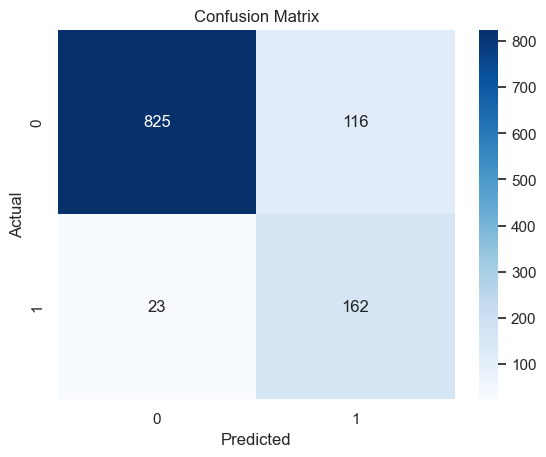

In [281]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

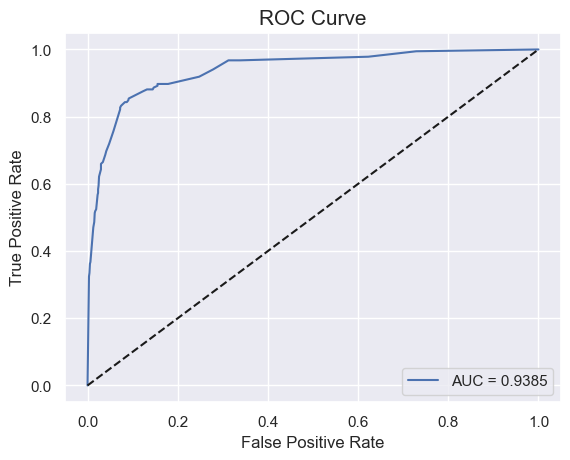

In [283]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = dtree.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=['y_actual']), pd.DataFrame(y_pred_proba, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_test.index

fpr, tpr, tr = roc_curve(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])
auc = roc_auc_score(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])

plt.plot(fpr, tpr, label='AUC = %0.4f' %auc)
plt.plot(fpr, fpr, linestyle = '--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', size = 15)
plt.legend()

## Model Interpretation

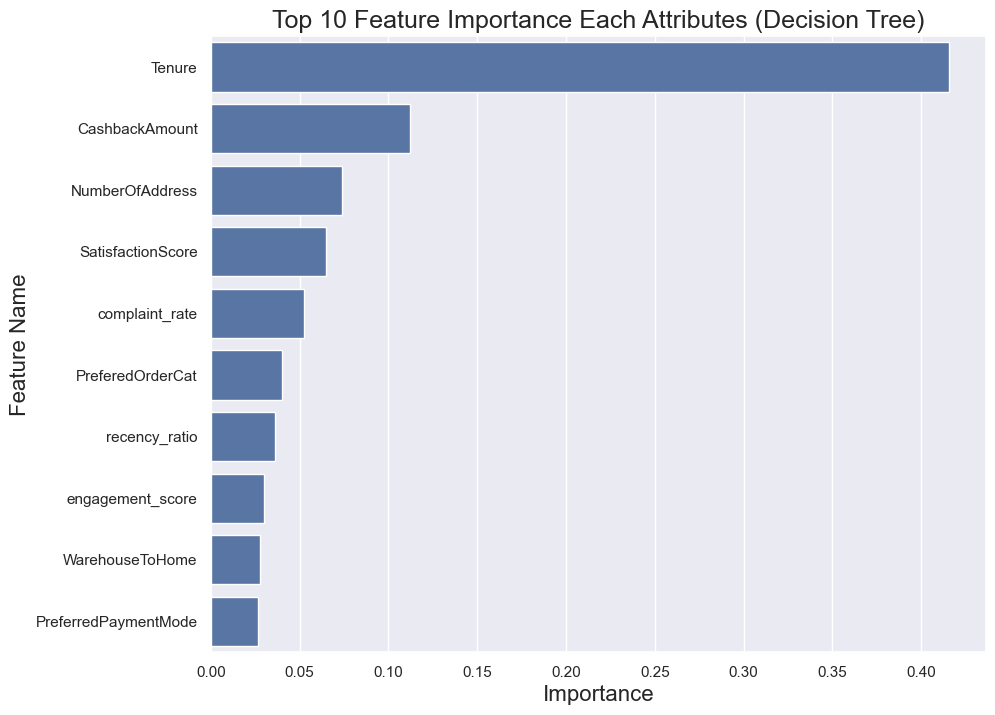

In [181]:
imp_df = pd.DataFrame({
    "Feature Name": X_train.columns,
    "Importance": dtree.feature_importances_
})
fi = imp_df.sort_values(by="Importance", ascending=False)

fi2 = fi.head(10)
plt.figure(figsize=(10,8))
sns.barplot(data=fi2, x='Importance', y='Feature Name')
plt.title('Top 10 Feature Importance Each Attributes (Decision Tree)', fontsize=18)
plt.xlabel ('Importance', fontsize=16)
plt.ylabel ('Feature Name', fontsize=16)
plt.show()

# Random Forest

In [300]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rfc = RandomForestClassifier(class_weight='balanced')
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'random_state': [0, 42]
}

## Hyperparameter Tuning

In [301]:
# Perform a grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(rfc, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(grid_search.best_params_)

{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200, 'random_state': 42}


In [302]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=0, max_features='sqrt', n_estimators=100, class_weight='balanced')
rfc.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=0)

## Model Evaluation

In [303]:
y_pred = rfc.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 97.87 %


In [308]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,  jaccard_score, log_loss

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100 ,5), "%")
print("Precision:", round(precision_score(y_test, y_pred)*100 ,5), "%")
print("Recall:", round(recall_score(y_test, y_pred)*100 ,5), "%")
print("F1 Score:", round(f1_score(y_test, y_pred)*100 ,5), "%")
print("Jaccard Score:", round(jaccard_score(y_test, y_pred)*100 ,5), "%")
print("Log Loss:", log_loss(y_test, y_pred))

Accuracy: 97.86856 %
Precision: 99.3865 %
Recall: 87.56757 %
F1 Score: 93.10345 %
Jaccard Score: 87.09677 %
Log Loss: 0.7682483848479681


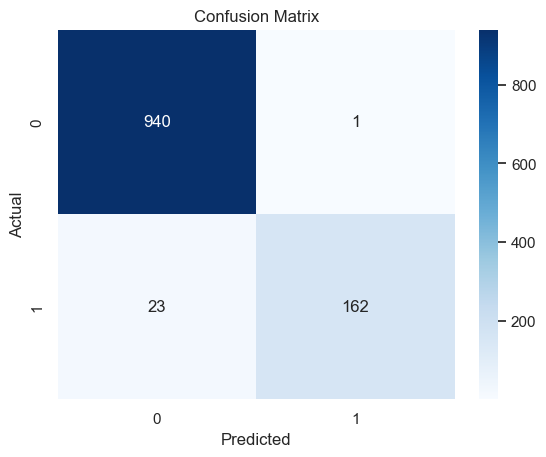

In [310]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

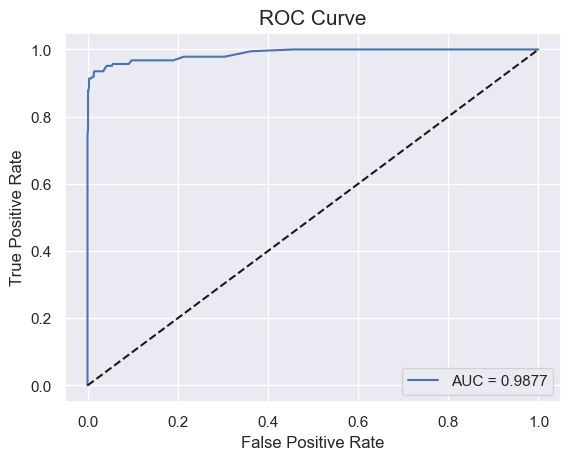

In [312]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = rfc.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=['y_actual']), pd.DataFrame(y_pred_proba, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_test.index

fpr, tpr, tr = roc_curve(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])
auc = roc_auc_score(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])

plt.plot(fpr, tpr, label='AUC = %0.4f' %auc)
plt.plot(fpr, fpr, linestyle = '--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', size = 15)
plt.legend()

## Model Interpretation